# Stage 4: RL LOD Policy Training — REINFORCE (Bootstrap-Fixed)

Trains the Stage 4 policy on `rollout_ep*.csv` collected by `RLRolloutLogger`.
Exports `rl_policy_stage4.onnx` consumed by `RLPolicyController` and
`rl_scaler_constants.json` consumed by `RLFeatureExtractor`.

This notebook is aligned to the actual Stage 4 runtime loop:
- rollout actions are emitted by `RLPolicyController` after dead-zone and dwell guards
- bootstrap rollout data is quantized (`-0.05`, `0.0`, `+0.05`) and mostly deterministic
- Unity deploys only the policy mean `mu` (`output[0]`), not a learned `sigma`

**Input**: `ml_pipeline/data/RLRollouts/rollout_ep*.csv`
**Output**: `ml_pipeline/models/Stage_4/rl_policy_stage4.onnx` + `rl_scaler_constants.json`

### Feature order (must match `RLFeatureExtractor.ExpectedFeatureNames` exactly)
| idx | name | notes |
|-----|------|-------|
| 0 | cpu_frame_time | ms — diagnostic only |
| 1 | gpu_frame_time | ms — reward signal source |
| 2 | fps | 1/deltaTime |
| 3 | visible_renderer_count | frustum sweep, not URP profiler |
| 4 | triangle_count | profiler recorder |
| 5 | draw_call_count | profiler recorder |
| 6 | camera_speed | m/s |
| 7 | camera_rotation_speed | deg/s |
| 8 | avg_screen_coverage | SSIM proxy |
| 9 | previous_bias | lodBias prior frame |
| 10 | recent_lod_switch_count | ring buffer count |

### Reward formula (matches `RLEvaluationLogger`)
```
r_t = (gpu_prev - gpu_t) + BONUS_SCALE * (gpu_t <= T_TARGET)
```


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sympy==1.12', 'optuna', '--quiet'])
print('Dependencies OK')

Dependencies OK


In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
BASE_DIR       = Path('../..').resolve()
DATA_DIR        = BASE_DIR / 'data' / 'RLRollouts'
MODEL_DIR       = BASE_DIR / 'models' / 'Stage_4'
PLOTS_DIR       = BASE_DIR / 'plots' / 'Stage_4' / 'Train'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Reward: improvement-based (matches RLEvaluationLogger)
T_TARGET         = 4.5
BONUS_SCALE      = 1.0
REWARD_CLIP      = 5.0
GPU_VALID_MIN_MS = 0.10
GPU_VALID_MAX_MS = 33.3

# Legacy weights (not used in reward; retained for report parity)
ALPHA            = 1.0
BETA             = 0.5
GAMMA_W          = 0.0
N_MAX            = 30.0

# REINFORCE / bootstrap-policy training hyperparameters
GAMMA_RL          = 0.99
TRAIN_SIGMA       = 0.10   # fixed training sigma; Unity deploys mu only
ACTION_HEAD_SCALE = 0.06   # bootstrap phase: match observed fallback support (+/-0.05) with small margin
PG_COEF           = 0.10   # heuristic rollouts are off-policy and mostly zero; downweight REINFORCE during bootstrap
BC_COEF           = 0.25   # behavior-cloning anchor for quantized bootstrap actions
NONZERO_BC_WEIGHT = 4.0    # bootstrap actions are ~92% zeros; upweight the rare real switches
SUPPORT_MARGIN    = 0.01   # allow slight smoothing beyond observed +/-0.05 bootstrap support
SUPPORT_COEF      = 20.0   # penalize outputs that leave the observed bootstrap action envelope
SAT_COEF          = 2.0    # mild far-cap safety penalty near +/-0.20
GRAD_CLIP         = 1.0
BATCH_SIZE        = 256
RANDOM_SEED       = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

FEATURE_COUNT = 11
FEATURE_COLS  = [
    'cpu_frame_time',
    'gpu_frame_time',
    'fps',
    'visible_renderer_count',
    'triangle_count',
    'draw_call_count',
    'camera_speed',
    'camera_rotation_speed',
    'avg_screen_coverage',
    'previous_bias',
    'recent_lod_switch_count'
]

print(f'Device:            {device}')
print(f'DATA_DIR:          {DATA_DIR}')
print(f'TRAIN_SIGMA:       {TRAIN_SIGMA:.3f}')
print(f'ACTION_HEAD_SCALE: {ACTION_HEAD_SCALE:.3f}')
print(f'PG_COEF:           {PG_COEF:.2f}')
print(f'BC_COEF:           {BC_COEF:.2f}')
print(f'NONZERO_BC_WEIGHT: {NONZERO_BC_WEIGHT:.2f}')
print(f'SUPPORT_MARGIN:    {SUPPORT_MARGIN:.3f}')
print(f'SUPPORT_COEF:      {SUPPORT_COEF:.2f}')
print(f'SAT_COEF:          {SAT_COEF:.2f}')
print(f'GPU valid ms:      [{GPU_VALID_MIN_MS:.2f}, {GPU_VALID_MAX_MS:.1f}]')


Device:            cuda
DATA_DIR:          C:\Users\Gica\neural-lod\ml_pipeline\data\RLRollouts
TRAIN_SIGMA:       0.100
ACTION_HEAD_SCALE: 0.060
PG_COEF:           0.10
BC_COEF:           0.25
NONZERO_BC_WEIGHT: 4.00
SUPPORT_MARGIN:    0.010
SUPPORT_COEF:      20.00
SAT_COEF:          2.00
GPU valid ms:      [0.10, 33.3]


## 1. Load Rollout CSVs
Reads `rollout_ep*.csv` files produced by `RLRolloutLogger`.  
Run the Unity scene in rule-based mode first if no files are found here.

In [4]:
def _col(df, *names, default=0.0):
    """Return the first matching column as a Series, or a constant Series if none found.
    Always returns a pd.Series — never a scalar — so .fillna() and .diff() are always safe.
    Handles run_00 (7 columns) through run_6_Turbo (24 columns) transparently."""
    for name in names:
        if name in df.columns:
            return df[name]
    return pd.Series(np.full(len(df), default), dtype=float)

rollout_files  = sorted(DATA_DIR.glob('rollout_ep*.csv'))
train_files    = sorted(DATA_DIR.rglob('training_data_*.csv'))
fallback_files = sorted(DATA_DIR.rglob('inference_eval_*.csv'))

if not rollout_files and not train_files and MERGED_FILE.exists():
    train_files = [MERGED_FILE]

print(f'rollout_ep*.csv      : {len(rollout_files)}')
print(f'training_data_*.csv  : {len(train_files)}')
print(f'inference_eval_*.csv : {len(fallback_files)}')

USING_FALLBACK = False
DATA_FORMAT    = 'native'
dfs = []

if rollout_files:
    DATA_FORMAT = 'rollout'
    print('\nUsing native rollout_ep*.csv (tier 1).')
    for f in rollout_files:
        df = pd.read_csv(f)
        df['source_file'] = f.name
        dfs.append(df)

elif train_files:
    # tier 2 — Stage 1 MetricLogger training_data_*.csv
    # Column mapping (direct — no derivation except recent_lod_switch_count):
    #   cpu_frame_time        <- cpu_frame_time_ms
    #   gpu_frame_time        <- gpu_frame_time_ms
    #   fps                   <- fps
    #   visible_renderer_count <- visible_renderer_count
    #   triangle_count        <- triangle_count
    #   draw_call_count       <- draw_calls (newer) or draw_call_estimate (older)
    #   camera_speed          <- camera_velocity  (pre-computed by MetricLogger)
    #   camera_rotation_speed <- camera_angular_velocity (pre-computed; absent in run_00)
    #   avg_screen_coverage   <- screen_coverage  (absent in run_00)
    #   previous_bias         <- previous_bias    (absent in run_00, derived from lod_bias_current)
    #   recent_lod_switch_count <- rolling 30-frame count from lod_bias_current
    USING_FALLBACK = True
    DATA_FORMAT    = 'train_runs'
    print(f'\nUsing training_data_*.csv (tier 2) — {len(train_files)} files.')
    print('All 11 RL features map directly. No zero-filling required.\n')

    for ep_idx, f in enumerate(train_files):
        df = pd.read_csv(f)

        mapped = pd.DataFrame()
        mapped['episode'] = ep_idx
        mapped['step']    = np.arange(len(df))

        # timing
        mapped['cpu_frame_time'] = pd.to_numeric(_col(df, 'cpu_frame_time_ms'), errors='coerce').fillna(0)
        mapped['gpu_frame_time'] = pd.to_numeric(_col(df, 'gpu_frame_time_ms'), errors='coerce').fillna(0)
        mapped['fps']            = pd.to_numeric(_col(df, 'fps', default=60.0), errors='coerce').fillna(60.0)

        # renderer stats
        mapped['visible_renderer_count'] = pd.to_numeric(_col(df, 'visible_renderer_count'), errors='coerce').fillna(0)
        mapped['triangle_count']         = pd.to_numeric(_col(df, 'triangle_count'),          errors='coerce').fillna(0)

        # draw calls — newer runs have draw_calls, older have draw_call_estimate
        mapped['draw_call_count'] = pd.to_numeric(_col(df, 'draw_calls', 'draw_call_estimate'), errors='coerce').fillna(0)

        # camera motion — pre-computed by MetricLogger
        # camera_angular_velocity absent in run_00; _col returns zeros Series safely
        mapped['camera_speed']          = pd.to_numeric(_col(df, 'camera_velocity'),          errors='coerce').fillna(0)
        mapped['camera_rotation_speed'] = pd.to_numeric(_col(df, 'camera_angular_velocity'),  errors='coerce').fillna(0)

        # screen coverage — absent in run_00
        mapped['avg_screen_coverage'] = pd.to_numeric(_col(df, 'screen_coverage'), errors='coerce').fillna(0)

        # bias — previous_bias absent in run_00, derive from lod_bias_current shift
        bias_cur = pd.to_numeric(_col(df, 'lod_bias_current', default=1.0), errors='coerce').fillna(1.0)
        prev_bias = pd.to_numeric(_col(df, 'previous_bias', default=1.0), errors='coerce').fillna(1.0)
        # if previous_bias column missing, derive it from lod_bias_current shift
        if 'previous_bias' not in df.columns:
            prev_bias = bias_cur.shift(1).fillna(1.0)
        mapped['previous_bias'] = prev_bias

        # recent_lod_switch_count — rolling 30-frame window of bias changes
        bias_changed = (bias_cur.diff().abs() > 0.01).astype(float)
        mapped['recent_lod_switch_count'] = bias_changed.rolling(30, min_periods=1).sum().fillna(0)

        # action columns — collection runs, no policy active
        mapped['lod_bias_before_action'] = mapped['previous_bias']
        mapped['lod_bias_after_action']  = bias_cur
        mapped['action_delta']           = 0.0

        mapped['source_file'] = f.name
        dfs.append(mapped)

elif fallback_files:
    USING_FALLBACK = True
    DATA_FORMAT    = 'inference_eval'
    print(f'\nWARNING: Using inference_eval_*.csv (tier 3) — {len(fallback_files)} files.')
    print('Prefer Train_Runs data. camera_speed/rotation derived from position deltas.\n')

    for ep_idx, f in enumerate(fallback_files):
        df = pd.read_csv(f)
        mapped = pd.DataFrame()
        mapped['episode']        = ep_idx
        mapped['step']           = _col(df, 'frame').astype(int) if 'frame' in df.columns else pd.Series(np.arange(len(df)))
        mapped['cpu_frame_time'] = pd.to_numeric(_col(df, 'cpu_ms', 'cpu_frame_time'), errors='coerce').fillna(0)
        mapped['gpu_frame_time'] = pd.to_numeric(_col(df, 'gpu_ms', 'gpu_frame_time'), errors='coerce').fillna(0)
        mapped['fps']            = pd.to_numeric(_col(df, 'fps', default=60.0),         errors='coerce').fillna(60.0)
        mapped['visible_renderer_count'] = pd.to_numeric(_col(df, 'visible_renderer_count'), errors='coerce').fillna(0)
        mapped['triangle_count']         = pd.to_numeric(_col(df, 'triangle_count'),         errors='coerce').fillna(0)
        mapped['draw_call_count']        = pd.to_numeric(_col(df, 'draw_call_count'),         errors='coerce').fillna(0)
        mapped['avg_screen_coverage']    = pd.to_numeric(_col(df, 'screen_coverage', 'avg_screen_coverage'), errors='coerce').fillna(0)
        if 'cam_pos_x' in df.columns:
            dx = df['cam_pos_x'].diff().fillna(0)
            dy = df['cam_pos_y'].diff().fillna(0)
            dz = df['cam_pos_z'].diff().fillna(0)
            dt = (1.0 / mapped['fps'].replace(0, 60.0))
            mapped['camera_speed'] = (np.sqrt(dx**2 + dy**2 + dz**2) / dt).fillna(0).clip(0, 50)
        else:
            mapped['camera_speed'] = 0.0
        if 'cam_rot_y' in df.columns:
            drot = df['cam_rot_y'].diff().fillna(0).abs()
            dt   = (1.0 / mapped['fps'].replace(0, 60.0))
            mapped['camera_rotation_speed'] = (drot / dt).fillna(0).clip(0, 360)
        else:
            mapped['camera_rotation_speed'] = 0.0
        bias = pd.to_numeric(_col(df, 'lod_bias_applied', default=1.0), errors='coerce').fillna(1.0)
        mapped['previous_bias']           = bias.shift(1).fillna(1.0)
        mapped['lod_bias_before_action']  = mapped['previous_bias']
        mapped['lod_bias_after_action']   = bias
        bias_changed = (bias.diff().abs() > 0.01).astype(float)
        mapped['recent_lod_switch_count'] = bias_changed.rolling(30, min_periods=1).sum().fillna(0)
        mapped['action_delta']  = 0.0
        mapped['source_file']   = f.name
        dfs.append(mapped)

else:
    raise FileNotFoundError(
        f'No training data found.\n'
        f'Expected one of:\n'
        f'  {DATA_DIR}/**/rollout_ep*.csv       (tier 1)\n'
        f'  {DATA_DIR}/**/training_data_*.csv   (tier 2)\n'
        f'  {MERGED_FILE}                        (tier 2 merged)\n'
        f'  {DATA_DIR}/**/inference_eval_*.csv  (tier 3)\n'
    )

raw = pd.concat(dfs, ignore_index=True)

all_cols = ['episode', 'step', 'cpu_frame_time', 'gpu_frame_time', 'fps',
            'visible_renderer_count', 'triangle_count', 'draw_call_count',
            'camera_speed', 'camera_rotation_speed', 'avg_screen_coverage',
            'previous_bias', 'recent_lod_switch_count',
            'lod_bias_before_action', 'action_delta', 'lod_bias_after_action']
for col in all_cols:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')

print(f'Raw rows  : {len(raw):,}')
print(f'Episodes  : {raw["episode"].nunique()}')
print(f'Steps/ep  : {raw.groupby("episode").size().mean():.0f}')
print(f'Format    : {DATA_FORMAT}')

nonzero = (raw[FEATURE_COLS] != 0).mean() * 100
print('\nFeature non-zero % (all should be >> 0 for valid training):')
print(nonzero.to_string())

zero_feats = nonzero[nonzero < 1.0].index.tolist()
if zero_feats:
    print(f'\nWARNING: {len(zero_feats)} near-all-zero features: {zero_feats}')
    print('Do NOT export ONNX. Use Train_Runs (tier 2) or rollouts (tier 1).')
raw.head(3)


rollout_ep*.csv      : 29
training_data_*.csv  : 0
inference_eval_*.csv : 0

Using native rollout_ep*.csv (tier 1).
Raw rows  : 26,065
Episodes  : 8
Steps/ep  : 3258
Format    : rollout

Feature non-zero % (all should be >> 0 for valid training):
cpu_frame_time             100.000000
gpu_frame_time             100.000000
fps                         99.938615
visible_renderer_count      99.125264
triangle_count              99.938615
draw_call_count             99.938615
camera_speed                67.887972
camera_rotation_speed       56.232496
avg_screen_coverage         99.125264
previous_bias               99.938615
recent_lod_switch_count     60.276232


,episode,step,cpu_frame_time,gpu_frame_time,fps,visible_renderer_count,triangle_count,draw_call_count,camera_speed,camera_rotation_speed,avg_screen_coverage,previous_bias,recent_lod_switch_count,lod_bias_before_action,action_delta,lod_bias_after_action,source_file
0,0,0,16.7337,0.3502,0.0,0,0,0,0.0,0.0,0.0,0.0,0,1.0,0.0,1.0,rollout_ep0000_20260404_004628.csv
1,0,1,16.6983,0.3502,0.0,0,0,0,0.0,0.0,0.0,0.0,0,1.0,0.0,1.0,rollout_ep0000_20260404_004628.csv
2,0,2,18.1153,0.3502,0.0,0,0,0,0.0,0.0,0.0,0.0,0,1.0,0.0,1.0,rollout_ep0000_20260404_004628.csv


make sure the data loaded is compatible

In [5]:
# AFTER concatenating dfs into raw

raw = pd.concat(dfs, ignore_index=True)

# =========================
# FIX: REBUILD EPISODES
# =========================
if raw['episode'].isna().all():
    print("Fixing missing episode column...")

    # create episode from step reset
    raw['episode'] = (raw['step'] == 0).cumsum()

    # fallback if no reset exists
    if raw['episode'].nunique() == 1:
        print("No step reset detected → single episode fallback")
        raw['episode'] = 0

print("Episodes after fix:", raw['episode'].nunique())

Episodes after fix: 8


## 2. Data Cleaning
Remove corrupt or warmup frames using the same GPU validity window implied by the Stage 4 docs and scripts.
Bootstrap rollouts are expected to be quantized because `RLPolicyController` applies a dead zone and dwell guard before logging `action_delta`.

In [6]:
# Remove invalid / corrupt timing rows
# Stage_4.md and the runtime scripts both imply that GPU <= 0 is invalid and large spikes
# are driver stalls or warmup artifacts, not real control targets.
df_clean = raw[
    (raw['cpu_frame_time'] > 0) &
    (raw['gpu_frame_time'] >= GPU_VALID_MIN_MS) &
    (raw['gpu_frame_time'] <= GPU_VALID_MAX_MS)
].copy()

print(f'After timing filter: {len(df_clean):,} rows ({100*len(df_clean)/len(raw):.1f}% kept)')

if len(df_clean) == 0:
    raise ValueError('All rows removed by timing filter -- check rollout collection')

# Drop rows that are missing essential training fields
df_clean = df_clean.dropna(subset=FEATURE_COLS + ['action_delta']).copy()
print(f'After NaN drop:      {len(df_clean):,} rows')

if len(df_clean) == 0:
    raise ValueError('All rows removed after NaN drop')

# Quantized action profile from RLPolicyController fallback + guardrails
a = pd.to_numeric(df_clean['action_delta'], errors='coerce').fillna(0).astype('float32')
action_counts = a.value_counts().sort_index()

print('Bootstrap action distribution:')
print(action_counts.to_string())
print(f'Non-zero action % : {(a.abs() > 1e-6).mean()*100:.1f}')
print(f'Near-zero action %: {(a.abs() < 0.005).mean()*100:.1f}')

# Episode stats summary
ep_stats = df_clean.groupby('episode').agg(
    steps=('step', 'count'),
    mean_gpu=('gpu_frame_time', 'mean'),
    mean_fps=('fps', 'mean'),
    mean_bias=('lod_bias_after_action', 'mean')
).round(3)
print(f'Episode summary ({len(ep_stats)} episodes):')
display(ep_stats.head(10))


After timing filter: 26,028 rows (99.9% kept)
After NaN drop:      26,028 rows
Bootstrap action distribution:
action_delta
-0.05      956
 0.00    23056
 0.05     2016
Non-zero action % : 11.4
Near-zero action %: 88.6
Episode summary (8 episodes):


,steps,mean_gpu,mean_fps,mean_bias
episode,,,,
0,7068,7.786,64.631,1.742
1,5599,8.762,59.823,1.620
2,4336,6.090,60.203,1.879
3,3880,6.084,59.932,1.882
4,2073,5.598,60.906,1.860
5,1024,5.125,61.928,1.918
6,1024,5.639,61.729,1.897
7,1024,5.838,63.038,1.884


## 3. Feature Scaling
Fit `StandardScaler` on the 11-feature state vector and save `rl_scaler_constants.json`.  
Copy this JSON to `Assets/StreamingAssets/` for `RLFeatureExtractor` to load at runtime.

Episodes: 8
RAW shape: (26065, 17)
After invalid: (26065, 17)
p99 NaNs: 0
After clip: (26065, 17)

NaN counts:
cpu_frame_time             0
gpu_frame_time             0
fps                        0
visible_renderer_count     0
triangle_count             0
draw_call_count            0
camera_speed               0
camera_rotation_speed      0
avg_screen_coverage        0
previous_bias              0
recent_lod_switch_count    0
action_delta               0
dtype: int64
After dropna: (26065, 17)
FINAL df_clean: (26065, 17)
Scaling OK: (26065, 11)
All feature scales valid
Saved: C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_scaler_constants.json


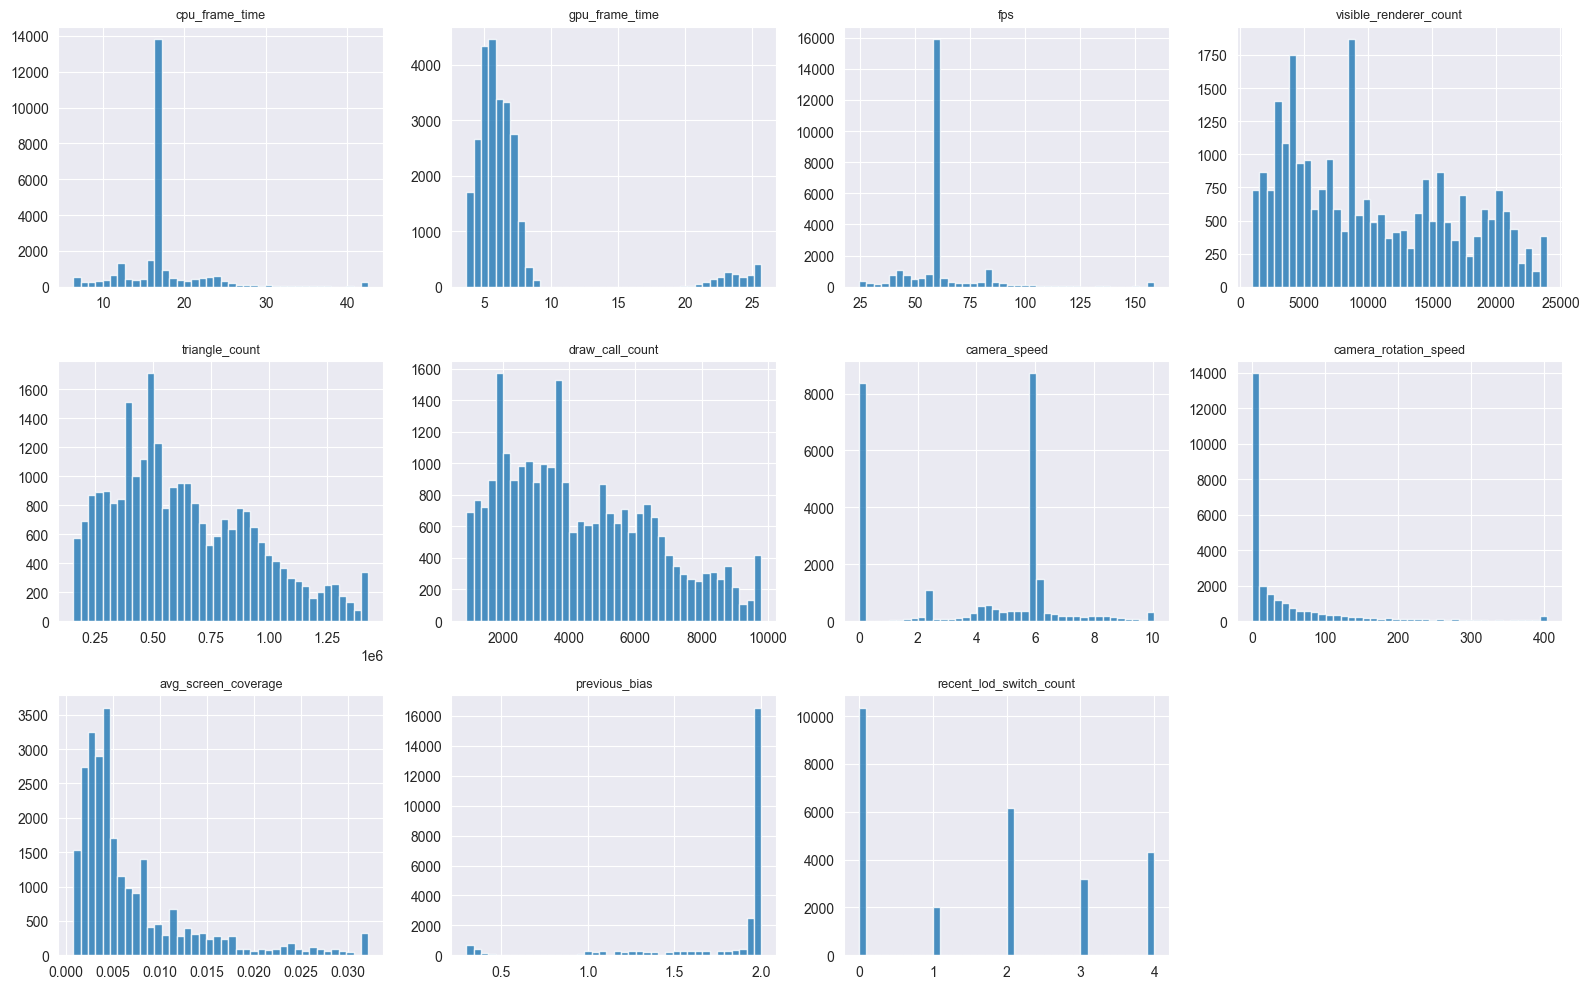

Final rows: 26065
Episodes: 8


In [7]:
# =========================
# STEP 0: FIX EPISODES (MANDATORY)
# =========================
raw = raw.copy()

if raw['episode'].isna().all():
    print("Fixing missing episode column...")
    raw['episode'] = (raw['step'] == 0).cumsum()

    if raw['episode'].nunique() == 1:
        print("No step reset detected → single episode fallback")
        raw['episode'] = 0

print("Episodes:", raw['episode'].nunique())
print("RAW shape:", raw.shape)

# =========================
# STEP 1: INVALID FILTER
# =========================
df_clean = raw[
    (raw['gpu_frame_time'] > 0) &
    (raw['cpu_frame_time'] > 0)
].copy()

print("After invalid:", df_clean.shape)

if len(df_clean) == 0:
    raise ValueError("All data removed at invalid filter")

# =========================
# STEP 2: OUTLIER CLIP (NO ROW REMOVAL)
# =========================
p99 = df_clean.groupby('episode')['gpu_frame_time'].transform(lambda x: x.quantile(0.99))

print("p99 NaNs:", p99.isna().sum())

df_clean['gpu_frame_time'] = np.minimum(df_clean['gpu_frame_time'], p99)

print("After clip:", df_clean.shape)

# =========================
# STEP 3: NaN DEBUG + SAFE CLEAN
# =========================
nan_counts = df_clean[FEATURE_COLS + ['action_delta']].isna().sum()
print("\nNaN counts:")
print(nan_counts)

# drop only essential features (NOT aggressive)
df_clean = df_clean.dropna(subset=FEATURE_COLS).copy()

print("After dropna:", df_clean.shape)

if len(df_clean) == 0:
    raise ValueError("All data removed at NaN drop")

# =========================
# STEP 4: FINAL CHECK
# =========================
print("FINAL df_clean:", df_clean.shape)

# =========================
# STEP 5: SCALING
# =========================
X_raw = df_clean[FEATURE_COLS].values.astype(np.float32)

if X_raw.shape[0] == 0:
    raise ValueError("No samples available for scaling")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

print("Scaling OK:", X_scaled.shape)

# =========================
# STEP 6: VALIDATION
# =========================
zero_scale = [
    (name, s)
    for name, s in zip(FEATURE_COLS, scaler.scale_)
    if s < 1e-8
]

if zero_scale:
    print("WARNING zero-scale:", zero_scale)
else:
    print("All feature scales valid")

# =========================
# STEP 7: SAVE SCALER
# =========================
scaler_data = {
    'feature_names': FEATURE_COLS,
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist()
}

scaler_path = MODEL_DIR / 'rl_scaler_constants.json'

with open(scaler_path, 'w') as f:
    json.dump(scaler_data, f, indent=2)

print("Saved:", scaler_path)

# =========================
# STEP 8: FEATURE DISTRIBUTIONS
# =========================
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    col_data = df_clean[col]

    if col_data.notna().sum() == 0:
        axes[i].set_visible(False)
        continue

    clipped = col_data.clip(
        lower=col_data.quantile(0.01),
        upper=col_data.quantile(0.99)
    )

    axes[i].hist(clipped, bins=40, alpha=0.8)
    axes[i].set_title(col, fontsize=9)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_distributions.png', dpi=150)
plt.show()

# =========================
# FINAL SAFETY CHECK
# =========================
print("Final rows:", len(df_clean))
print("Episodes:", df_clean['episode'].nunique())

## 4. Reward Computation

**Improvement-based reward** (fixes always-negative policy collapse):
```
r_t = (gpu_prev - gpu_t)                   # positive when GPU time decreases
    + BONUS_SCALE * (gpu_t <= T_TARGET)    # bonus for staying under budget
```
Switch penalty removed (`GAMMA_W=0`): penalising switches caused policy inaction.


In [8]:
# IMPROVEMENT-BASED REWARD
# r_t = (gpu_prev - gpu_t) + BONUS_SCALE * (gpu_t <= T_TARGET)
#
# Reference: Stage_4_rl_failure_diagnosis_and_fix.md sections 4-12.

df_clean = df_clean.sort_values(['episode', 'step']).reset_index(drop=True)

gpu      = df_clean['gpu_frame_time'].values.astype('float32')
gpu_prev = (
    df_clean.groupby('episode')['gpu_frame_time']
    .shift(1)
    .fillna(df_clean['gpu_frame_time'])  # first frame: no improvement signal
    .values.astype('float32')
)

r_improvement = gpu_prev - gpu
r_bonus       = (gpu <= T_TARGET).astype('float32') * BONUS_SCALE
rewards       = np.clip(r_improvement + r_bonus, -REWARD_CLIP, REWARD_CLIP).astype('float32')

if len(rewards) == 0:
    raise ValueError('rewards is empty -- df_clean is empty')

pos_pct = float((rewards > 0).mean() * 100)
print(f'Reward | mean={rewards.mean():.4f} std={rewards.std():.4f} '
      f'min={rewards.min():.4f} max={rewards.max():.4f}')
print(f'Positive steps: {(rewards > 0).sum():,}/{len(rewards):,} ({pos_pct:.1f}%)')

if pos_pct < 1.0:
    raise ValueError(
        f'Only {pos_pct:.1f}% positive rewards -- check GPU data quality.\n'
        'Ensure training_data_*.csv has valid per-frame gpu_frame_time_ms values.'
    )

df_clean = df_clean.copy()
df_clean['reward'] = rewards


Reward | mean=0.0859 std=2.3344 min=-5.0000 max=5.0000
Positive steps: 13,279/26,065 (50.9%)


## 5. Policy Network
Deterministic deployment policy MLP.
- **Input**: 11 normalized state features
- **Output**: action mean `mu` (scalar) bounded to the bootstrap support band `[-0.06, +0.06]` for fallback-policy training
- **Training log-prob sigma**: fixed constant `TRAIN_SIGMA` used only inside the REINFORCE loss
- ONNX exports only `mu` — Unity `RLPolicyController` reads `output[0]` deterministically


In [9]:
class PolicyMLP(nn.Module):
    """Stage 4 bootstrap policy: outputs action mean mu within the observed fallback support band."""
    def __init__(self, input_dim, h1, h2, h3, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),        nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h2, h3),        nn.GELU(),
            nn.Linear(h3, 1),
            nn.Tanh()
        )
        self.action_scale = ACTION_HEAD_SCALE

    def forward(self, x):
        return self.net(x) * self.action_scale


## 6. Hyperparameter Tuning (Optuna)


### Returns and Train/Val Split
Discounted returns `G_t` computed per episode, then normalized globally.


In [10]:
# REINFORCE Returns

if len(df_clean) == 0:
    raise ValueError('df_clean is empty')
if 'reward' not in df_clean.columns:
    raise ValueError("'reward' column missing -- run Reward Computation cell first")

pos_pct = float((df_clean['reward'] > 0).mean() * 100)
if pos_pct < 1.0:
    raise ValueError(f'Only {pos_pct:.1f}% positive rewards -- check reward cell')

def compute_returns(rewards_ep, gamma):
    G = np.zeros_like(rewards_ep, dtype='float32')
    running = 0.0
    for t in reversed(range(len(rewards_ep))):
        running = float(rewards_ep[t]) + gamma * running
        G[t] = running
    return G

df_clean = df_clean.sort_values(['episode', 'step']).reset_index(drop=True)
returns_list = []
for _, grp in df_clean.groupby('episode', sort=False):
    returns_list.append(compute_returns(grp['reward'].values, GAMMA_RL))

df_clean['G_t'] = np.concatenate(returns_list)
G_mean = df_clean['G_t'].mean()
G_std  = df_clean['G_t'].std() + 1e-8
df_clean['G_t_norm'] = (df_clean['G_t'] - G_mean) / G_std

print(f'Returns shape: {df_clean["G_t_norm"].shape}')
print(f'G_t   | mean={df_clean["G_t"].mean():.4f} std={df_clean["G_t"].std():.4f}')
print(f'G_norm| mean={df_clean["G_t_norm"].mean():.4f} std={df_clean["G_t_norm"].std():.4f}')


Returns shape: (26065,)
G_t   | mean=8.2840 std=19.9485
G_norm| mean=-0.0000 std=1.0000


Quick trials to find the best architecture and learning rate for the deployable `mu` policy.
The objective combines REINFORCE validation loss with action-fit and saturation penalties,
which is more faithful to the Stage 4 runtime than tuning raw loss alone.

In [11]:
from sklearn.model_selection import train_test_split
import logging
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

X_all = X_scaled
A_all = df_clean['action_delta'].values.astype('float32')
G_all = df_clean['G_t_norm'].values.astype('float32')

X_tr, X_val, A_tr, A_val, G_tr, G_val = train_test_split(
    X_all, A_all, G_all, test_size=0.15, random_state=RANDOM_SEED
)

X_tr_t  = torch.tensor(X_tr).to(device)
A_tr_t  = torch.tensor(A_tr).to(device)
G_tr_t  = torch.tensor(G_tr).to(device)
X_val_t = torch.tensor(X_val).to(device)
A_val_t = torch.tensor(A_val).to(device)
G_val_t = torch.tensor(G_val).to(device)

ACTION_SUPPORT = np.array(sorted(df_clean['action_delta'].dropna().unique().tolist()), dtype=np.float32)
ACTION_SUPPORT_ABS_MAX = float(np.max(np.abs(ACTION_SUPPORT)))
ACTION_SUPPORT_LIMIT = float(min(0.20, ACTION_SUPPORT_ABS_MAX + SUPPORT_MARGIN))
print(f'Observed rollout action support: {ACTION_SUPPORT.tolist()}')
print(f'Bootstrap support limit: +/-{ACTION_SUPPORT_LIMIT:.3f}')


def reinforce_loss(model, X, A, G):
    """REINFORCE loss for the deployable mean policy.

    Key design choice from data/script analysis:
    - Unity deploys only mu
    - bootstrap rollouts are quantized by dead zone + dwell guard
    - observed rollout support is only {-0.05, 0.00, +0.05}

    So we train mu with:
    - downweighted fixed-sigma REINFORCE log-prob
    - weighted behavior cloning so rare non-zero actions are not drowned by zeros
    - support-envelope penalty to stop the policy leaving the bootstrap action band
    - mild far-cap safety penalty near +/-0.20
    """
    from torch.distributions import Normal

    mu = model(X).squeeze(1)
    sigma = torch.full_like(mu, TRAIN_SIGMA)
    dist = Normal(mu, sigma)

    pg_loss = -(G * dist.log_prob(A)).mean()

    bc_weight = torch.where(
        A.abs() > 1e-6,
        torch.full_like(A, NONZERO_BC_WEIGHT),
        torch.ones_like(A)
    )
    bc_loss = (bc_weight * F.smooth_l1_loss(mu, A, reduction='none')).mean()

    support_loss = ((mu.abs() - ACTION_SUPPORT_LIMIT).clamp(min=0.0) ** 2).mean()
    sat_loss = ((mu.abs() - 0.19).clamp(min=0.0) ** 2).mean()

    return PG_COEF * pg_loss + BC_COEF * bc_loss + SUPPORT_COEF * support_loss + SAT_COEF * sat_loss


def eval_metrics(model, X, A, G):
    model.eval()
    with torch.no_grad():
        mu = model(X).squeeze(1)
        val_loss = reinforce_loss(model, X, A, G).item()
        mae = torch.mean(torch.abs(mu - A)).item()
        support_viol_pct = torch.mean((mu.abs() > ACTION_SUPPORT_LIMIT).float()).item() * 100.0
        sat_pct = torch.mean((mu.abs() >= 0.19).float()).item() * 100.0
        pos_sat_pct = torch.mean((mu >= 0.19).float()).item() * 100.0
        neg_sat_pct = torch.mean((mu <= -0.19).float()).item() * 100.0
        zero_pct = torch.mean((mu.abs() < 0.005).float()).item() * 100.0
    return val_loss, mae, support_viol_pct, sat_pct, pos_sat_pct, neg_sat_pct, zero_pct


def run_trial(h1, h2, h3, lr, dropout, epochs=50):
    m   = PolicyMLP(FEATURE_COUNT, h1, h2, h3, dropout).to(device)
    opt = optim.AdamW(m.parameters(), lr=lr)
    n   = len(X_tr_t)

    for ep in range(epochs):
        m.train()
        idx = torch.randperm(n)
        for start in range(0, n, BATCH_SIZE):
            b = idx[start:start+BATCH_SIZE]
            opt.zero_grad()
            loss = reinforce_loss(m, X_tr_t[b], A_tr_t[b], G_tr_t[b])
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt.step()

    val_loss, mae, support_viol_pct, sat_pct, pos_sat_pct, neg_sat_pct, zero_pct = eval_metrics(
        m, X_val_t, A_val_t, G_val_t
    )

    score = val_loss + 0.35 * mae + 0.08 * support_viol_pct + 0.02 * sat_pct
    logging.info(
        f'  val_loss={val_loss:.4f} mae={mae:.4f} support%={support_viol_pct:.2f} '
        f'sat%={sat_pct:.2f} pos_sat%={pos_sat_pct:.2f} neg_sat%={neg_sat_pct:.2f} '
        f'zero%={zero_pct:.2f} score={score:.4f}'
    )
    return score


def objective(trial):
    h1      = trial.suggest_categorical('h1', [128, 256, 512])
    h2      = trial.suggest_categorical('h2', [64, 128, 256])
    h3      = trial.suggest_categorical('h3', [32, 64, 128])
    lr      = trial.suggest_float('lr', 5e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.05, 0.30)
    return run_trial(h1, h2, h3, lr, dropout)


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

logging.info(f'Best objective : {study.best_value:.6f}')
logging.info(f'Best params    : {study.best_params}')


Observed rollout action support: [-0.05000000074505806, 0.0, 0.05000000074505806]
Bootstrap support limit: +/-0.060


[2026-04-04 01:35:27,542] INFO -   val_loss=-0.0069 mae=0.0320 support%=0.00 sat%=0.00 pos_sat%=0.00 neg_sat%=0.00 zero%=48.08 score=0.0043
[2026-04-04 01:35:48,391] INFO -   val_loss=-0.0071 mae=0.0343 support%=0.00 sat%=0.00 pos_sat%=0.00 neg_sat%=0.00 zero%=41.59 score=0.0049
[2026-04-04 01:36:09,340] INFO -   val_loss=-0.0074 mae=0.0339 support%=0.00 sat%=0.00 pos_sat%=0.00 neg_sat%=0.00 zero%=42.23 score=0.0044
[2026-04-04 01:36:29,995] INFO -   val_loss=-0.0068 mae=0.0350 support%=0.00 sat%=0.00 pos_sat%=0.00 neg_sat%=0.00 zero%=27.52 score=0.0054
[2026-04-04 01:36:51,784] INFO -   val_loss=-0.0061 mae=0.0288 support%=0.00 sat%=0.00 pos_sat%=0.00 neg_sat%=0.00 zero%=55.58 score=0.0040
[2026-04-04 01:36:51,786] INFO - Best objective : 0.003996
[2026-04-04 01:36:51,787] INFO - Best params    : {'h1': 128, 'h2': 256, 'h3': 128, 'lr': 0.004537425127508577, 'dropout': 0.19923463889183624}


## Optuna Result
(Populated after running the tuning cell above.)


## 7. Final REINFORCE Training

[2026-04-04 01:36:51,803] INFO - Best params loaded: {'h1': 128, 'h2': 256, 'h3': 128, 'lr': 0.004537425127508577, 'dropout': 0.19923463889183624}
[2026-04-04 01:36:51,806] INFO - TRAINING START | epochs=150 lr=0.0045374 | fixed-sigma mu policy
[2026-04-04 01:36:52,279] INFO - Epoch 1/150 | train=-0.000857 | val=-0.005628 | mae=0.033623 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=25.35
[2026-04-04 01:36:52,733] INFO - Epoch 2/150 | train=-0.001572 | val=-0.005752 | mae=0.032856 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=36.93
[2026-04-04 01:36:53,181] INFO - Epoch 3/150 | train=-0.001604 | val=-0.005956 | mae=0.032920 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=33.63
[2026-04-04 01:36:53,631] INFO - Epoch 4/150 | train=-0.001730 | val=-0.005783 | mae=0.032324 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=44.17
[2026-04-04 01:36:54,070] INFO - Epoch 5/150 | train=-0.001783 | val=-0.006203 | ma

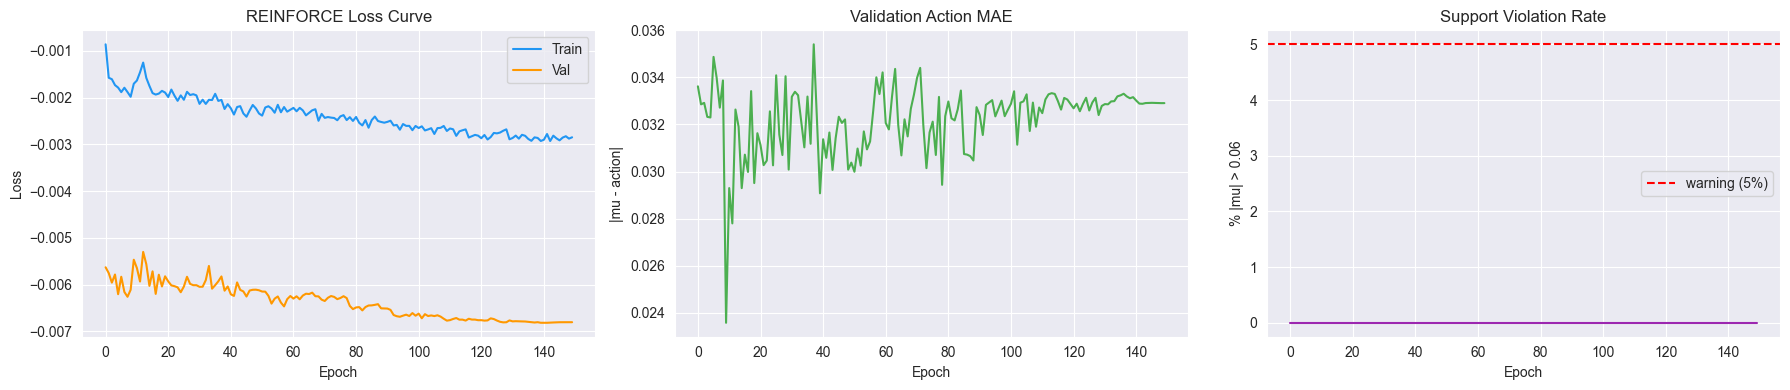

[2026-04-04 01:37:59,516] INFO - Final fixed training sigma: 0.1000
[2026-04-04 01:37:59,516] INFO - Final support violation rate: 0.00%
[2026-04-04 01:37:59,517] INFO - Final saturation rate: 0.00%


In [12]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

bp = study.best_params
logging.info(f'Best params loaded: {bp}')

model = PolicyMLP(
    FEATURE_COUNT,
    h1=bp['h1'], h2=bp['h2'], h3=bp['h3'],
    dropout=bp['dropout']
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=bp['lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

EPOCHS  = 150
history = {'train': [], 'val': [], 'mae': [], 'support_pct': [], 'sat_pct': []}
n       = len(X_tr_t)

logging.info(f'TRAINING START | epochs={EPOCHS} lr={bp["lr"]:.5g} | fixed-sigma mu policy')

for epoch in range(EPOCHS):
    model.train()
    idx = torch.randperm(n)
    t_losses = []

    for start in range(0, n, BATCH_SIZE):
        b = idx[start:start+BATCH_SIZE]
        optimizer.zero_grad()
        loss = reinforce_loss(model, X_tr_t[b], A_tr_t[b], G_tr_t[b])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        t_losses.append(loss.item())

    scheduler.step()

    v_loss, mae, support_viol_pct, sat_pct, pos_sat_pct, neg_sat_pct, zero_pct = eval_metrics(
        model, X_val_t, A_val_t, G_val_t
    )

    train_loss = np.mean(t_losses)
    history['train'].append(train_loss)
    history['val'].append(v_loss)
    history['mae'].append(mae)
    history['support_pct'].append(support_viol_pct)
    history['sat_pct'].append(sat_pct)

    logging.info(
        f'Epoch {epoch+1}/{EPOCHS} | train={train_loss:.6f} | val={v_loss:.6f} | '
        f'mae={mae:.6f} | support%={support_viol_pct:.2f} | sat%={sat_pct:.2f} | '
        f'pos_sat%={pos_sat_pct:.2f} | neg_sat%={neg_sat_pct:.2f} | zero%={zero_pct:.2f}'
    )

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ax = axes[0]
ax.plot(history['train'], label='Train', color='#2196F3')
ax.plot(history['val'],   label='Val',   color='#FF9800')
ax.set_title('REINFORCE Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

ax = axes[1]
ax.plot(history['mae'], color='#4CAF50')
ax.set_title('Validation Action MAE')
ax.set_xlabel('Epoch')
ax.set_ylabel('|mu - action|')

ax = axes[2]
ax.plot(history['support_pct'], color='#9C27B0')
ax.axhline(5.0, color='red', linestyle='--', label='warning (5%)')
ax.set_title('Support Violation Rate')
ax.set_xlabel('Epoch')
ax.set_ylabel(f'% |mu| > {ACTION_SUPPORT_LIMIT:.2f}')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'loss_curve.png', dpi=150)
plt.show()

final_support = history['support_pct'][-1]
final_sat = history['sat_pct'][-1]
logging.info(f'Final fixed training sigma: {TRAIN_SIGMA:.4f}')
logging.info(f'Final support violation rate: {final_support:.2f}%')
logging.info(f'Final saturation rate: {final_sat:.2f}%')
if final_support > 5.0:
    logging.warning('Predicted mu leaves bootstrap action support too often -- inspect diagnostics before export')


## 8. Policy Diagnostics
These diagnostics are aligned to the actual Stage 4 bootstrap regime:
- rollout actions are quantized by `RLPolicyController` (`-0.05`, `0.0`, `+0.05` in the current data)
- Unity deploys only `mu`
- the key health checks are action-fit and avoidance of `+/-0.20` collapse

[2026-04-04 01:37:59,533] INFO - Model device: cuda:0
[2026-04-04 01:37:59,534] INFO - Input device: cuda:0
[2026-04-04 01:37:59,548] INFO - Fixed training sigma: 0.100000
[2026-04-04 01:37:59,548] INFO - Bootstrap support limit: +/-0.060
[2026-04-04 01:37:59,549] INFO - Predicted mu stats | mean=0.019102 | std=0.038373 | min=-0.060000 | max=0.060000
[2026-04-04 01:37:59,550] INFO - Action fit | MAE=0.033175 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=45.46


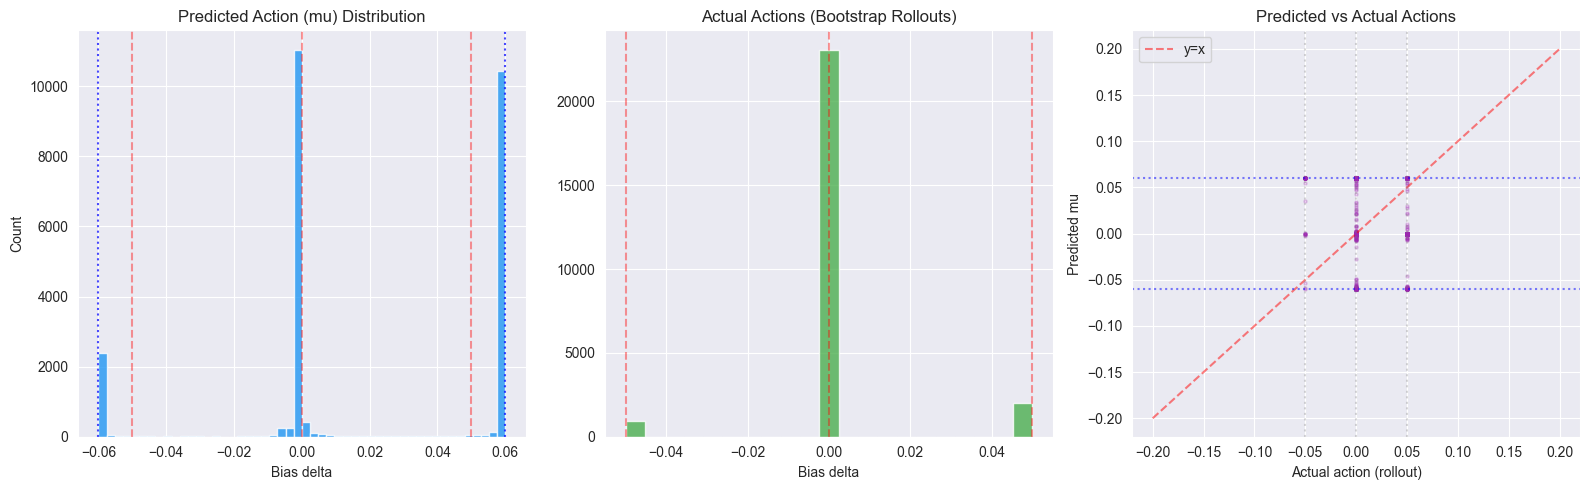

[2026-04-04 01:38:00,226] INFO - Saved: action_diagnostics.png


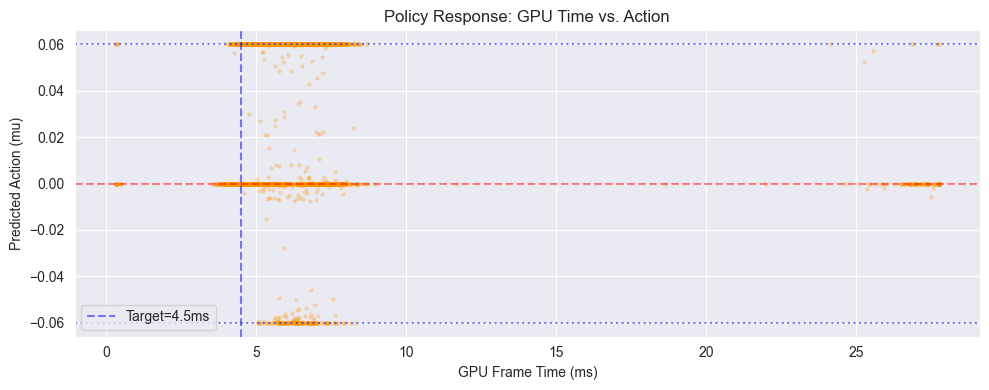

[2026-04-04 01:38:00,536] INFO - Saved: policy_response.png


In [13]:
import logging
import torch

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

model = model.to(device)
for name, buf in model.named_buffers():
    model._buffers[name] = buf.to(device)

X_all_t = torch.tensor(X_scaled, dtype=torch.float32, device=device)

logging.info(f'Model device: {next(model.parameters()).device}')
logging.info(f'Input device: {X_all_t.device}')

model.eval()
with torch.no_grad():
    mu_all = model(X_all_t).cpu().numpy().flatten()

actual_actions = df_clean['action_delta'].values.astype('float32')
mae_all = float(np.mean(np.abs(mu_all - actual_actions)))
support_viol_pct = float((np.abs(mu_all) > ACTION_SUPPORT_LIMIT).mean() * 100)
sat_pct = float((np.abs(mu_all) >= 0.19).mean() * 100)
pos_sat_pct = float((mu_all >= 0.19).mean() * 100)
neg_sat_pct = float((mu_all <= -0.19).mean() * 100)
zero_pct = float((np.abs(mu_all) < 0.005).mean() * 100)

logging.info(f'Fixed training sigma: {TRAIN_SIGMA:.6f}')
logging.info(f'Bootstrap support limit: +/-{ACTION_SUPPORT_LIMIT:.3f}')
logging.info(
    f'Predicted mu stats | mean={mu_all.mean():.6f} | std={mu_all.std():.6f} | '
    f'min={mu_all.min():.6f} | max={mu_all.max():.6f}'
)
logging.info(
    f'Action fit | MAE={mae_all:.6f} | support%={support_viol_pct:.2f} | '
    f'sat%={sat_pct:.2f} | pos_sat%={pos_sat_pct:.2f} | neg_sat%={neg_sat_pct:.2f} | zero%={zero_pct:.2f}'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted distribution
ax = axes[0]
ax.hist(mu_all, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
for v in sorted(np.unique(actual_actions)):
    ax.axvline(v, color='red', linestyle='--', alpha=0.4)
ax.axvline(ACTION_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.7)
ax.axvline(-ACTION_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.7)
ax.set_title('Predicted Action (mu) Distribution')
ax.set_xlabel('Bias delta')
ax.set_ylabel('Count')

# Actual actions
ax = axes[1]
ax.hist(actual_actions, bins=21, color='#4CAF50', alpha=0.8, edgecolor='white')
for v in sorted(np.unique(actual_actions)):
    ax.axvline(v, color='red', linestyle='--', alpha=0.4)
ax.set_title('Actual Actions (Bootstrap Rollouts)')
ax.set_xlabel('Bias delta')

# Scatter
ax = axes[2]
ax.scatter(actual_actions[:2000], mu_all[:2000], alpha=0.2, s=5, color='#9C27B0')
ax.plot([-0.2, 0.2], [-0.2, 0.2], 'r--', alpha=0.5, label='y=x')
for v in sorted(np.unique(actual_actions)):
    ax.axvline(v, color='gray', linestyle=':', alpha=0.3)
ax.axhline(ACTION_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
ax.axhline(-ACTION_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
ax.set_xlabel('Actual action (rollout)')
ax.set_ylabel('Predicted mu')
ax.set_title('Predicted vs Actual Actions')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'action_diagnostics.png', dpi=150)
plt.show()
logging.info('Saved: action_diagnostics.png')

plt.figure(figsize=(10, 4))
plt.scatter(
    df_clean['gpu_frame_time'].values[:3000],
    mu_all[:3000],
    alpha=0.2, s=5, color='#FF9800'
)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axhline(ACTION_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
plt.axhline(-ACTION_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
plt.axvline(T_TARGET, color='blue', linestyle='--', alpha=0.5, label=f'Target={T_TARGET}ms')
plt.xlabel('GPU Frame Time (ms)')
plt.ylabel('Predicted Action (mu)')
plt.title('Policy Response: GPU Time vs. Action')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'policy_response.png', dpi=150)
plt.show()
logging.info('Saved: policy_response.png')

if support_viol_pct > 5.0:
    logging.warning('mu leaves bootstrap action support too often -- do not export without reviewing diagnostics')


## 9. ONNX Export
Exports the deployable deterministic mean policy `mu` only. Unity `RLPolicyController` reads `output[0]` as the action delta.

In [14]:
pip install onnxruntime-gpu

Note: you may need to restart the kernel to use updated packages.


In [15]:
import onnxruntime as ort
print(ort.__version__)

1.24.4


In [16]:
# Quality gate before export -- do not mutate FEATURE_COLS or raw here
nonzero_pct = (df_clean[FEATURE_COLS] != 0).mean() * 100
zero_features = nonzero_pct[nonzero_pct < 1.0].index.tolist()
if zero_features:
    print(f'BLOCKED: {len(zero_features)} features are near-all-zero:')
    for fn in zero_features:
        print(f'  {fn}: {nonzero_pct[fn]:.1f}% non-zero')
    raise RuntimeError('ONNX export blocked -- near-zero feature columns detected.')

print('Quality gate passed. Proceeding with ONNX export.')


Quality gate passed. Proceeding with ONNX export.


In [17]:
onnx_path = MODEL_DIR / 'rl_policy_stage4.onnx'
export_model = model.cpu().eval()
dummy_input  = torch.zeros(1, FEATURE_COUNT, dtype=torch.float32)

torch.onnx.export(
    export_model,
    dummy_input,
    str(onnx_path),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print(f'ONNX exported → {onnx_path}')

import onnxruntime as ort
sess = ort.InferenceSession(str(onnx_path))
out  = sess.run(None, {'input': dummy_input.numpy()})[0]
print(f'ONNX output shape: {out.shape} | value: {out[0,0]:.6f}')
assert out.shape == (1, 1), f'Expected (1,1), got {out.shape}'
print('ONNX validation OK.')
print()
print(f'Next step: assign {onnx_path.name} to RLPolicyController.OnnxAsset in Unity.')


ONNX exported → C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_policy_stage4.onnx
ONNX output shape: (1, 1) | value: -0.059997
ONNX validation OK.

Next step: assign rl_policy_stage4.onnx to RLPolicyController.OnnxAsset in Unity.


## 10. Output Summary

In [18]:
print('Training complete.')
print(f'  Final val loss      : {history["val"][-1]:.4f}')
print(f'  Final val MAE       : {history["mae"][-1]:.4f}')
print(f'  Final support rate  : {history["support_pct"][-1]:.2f}%')
print(f'  Final sat rate      : {history["sat_pct"][-1]:.2f}%')
print(f'  Training sigma      : fixed {TRAIN_SIGMA:.3f}')


Training complete.
  Final val loss      : -0.0068
  Final val MAE       : 0.0329
  Final support rate  : 0.00%
  Final sat rate      : 0.00%
  Training sigma      : fixed 0.100
